In [2]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESMC2/bin'

In [3]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA')
from ESMCBA.imports import *
from ESMCBA import graph_utils

In [ ]:
>GABPA
MTKREAEELIEIEIDGTEKAECTEESIVEQTYAPAECVSQAIDINEPIGNLKKLLEPRLQCSLDAHEICLQDIQLDPERSLFDQGVKTDGTVQLSVQVISYQGIEPKLNILEIVKPADTVEVVIDPDAHHAESEAHLVEEAQVITLDGTKHITTISDETSEQVTRWAAALEGYRKEQERLGIPYDPIQWSTDQVLHWVVWVMKEFSMTDIDLTTLNISGRELCSLNQEDFFQRVPRGEILWSHLELLRKYVLASQEQQMNEIVTIDQPVQIIPASVQSATPTTIKVINSSAKAAKVQRAPRISGEDRSSPGNRTGNNGQIQLWQFLLELLTDKDARDCISWVGDEGEFKLNQPELVAQKWGQRKNKPTMNYEKLSRALRYYYDGDMICKVQGKRFVYKFVCDLKTLIGYSAAELNRLVTECEQKKLAKMQLHGIAQPVTAVALATASLQTEKDN*

In [6]:
pd.read_csv('/global/scratch/users/sergiomar10/B1_analysis_share_sergio.csv')

,seqid,Ref,position,mutation,average pTM,average ipTM,average pDockq,log_likelihood (AF2),log_likelihood_target (AF2),log_likelihood (CRYSTAL),...,pathogenicity score,pathogenicity class,ESM-C score,AF2 PTM rank,AF2 iPTM rank,AF2 pDockq rank,SE w/ AF2 rank,SE w/ crystal rank,ESM-C rank,nanobit score compared to WT
0,F136K,F,136,K,0.674703,0.380016,0.12952,-1.332567,-1.109067,-1.399666,...,0.9970,likely_pathogenic,-14.353198,3154,3153,3155,2625,2409.0,2984,NaN
1,F136D,F,136,D,0.675899,0.377514,0.13844,-1.323259,-1.083617,-1.389171,...,0.9936,likely_pathogenic,-9.871827,3153,3154,3154,2196,2084.0,2166,NaN
2,F136E,F,136,E,0.691073,0.418787,0.14620,-1.331438,-1.098604,-1.396234,...,0.9958,likely_pathogenic,-12.421714,3152,3152,3153,2580,2316.0,2755,NaN
3,D101R,D,101,R,0.732703,0.563493,0.14640,-1.338167,-1.118711,-1.410822,...,0.9999,likely_pathogenic,-11.169647,3151,3151,3152,2845,2700.0,2485,NaN
4,L103D,L,103,D,0.662558,0.363965,0.16112,-1.310180,-1.063589,-1.379671,...,0.9984,likely_pathogenic,-13.120021,3155,3155,3151,1706,1752.0,2867,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3150,T39R,T,39,R,0.870636,0.893575,0.35504,-1.291448,-1.031510,-1.360504,...,0.9770,likely_pathogenic,-8.136013,1920,1991,5,700,979.0,1667,NaN
3151,L103V,L,103,V,0.871469,0.893722,0.35512,-1.318029,-1.080555,-1.375882,...,0.9588,likely_pathogenic,-5.824292,953,1953,4,2015,1631.0,1021,NaN
3152,K135N,K,135,N,0.870944,0.891929,0.35560,-1.293799,-1.035376,-1.361695,...,0.9894,likely_pathogenic,-7.840663,1695,2356,3,839,1045.0,1576,NaN
3153,L103T,L,103,T,0.871892,0.893680,0.35796,-1.313976,-1.072988,-1.380174,...,0.9886,likely_pathogenic,-9.414154,324,1969,2,1851,1768.0,2038,NaN


In [1]:
pd.read_csv(‘../../B1_analysis_share_sergio.csv’)

SyntaxError: invalid character '‘' (U+2018) (1358971204.py, line 1)

In [3]:
directory = '/global/scratch/users/sergiomar10/logs/ESMC_Pretrain_logs_09042025'
csv_files = glob.glob(os.path.join(directory, '*.csv'))
data = []

for file in csv_files:
    if os.path.getsize(file) > 0:
        try:
            df = pd.read_csv(file)
            df = df.replace([np.inf, -np.inf], np.nan).dropna()

            base = os.path.basename(file)
            # Remove the file extension and split by underscore
            name_parts = os.path.splitext(base)[0].split('_')
            # Expected filename parts:
            # [0]: "training"
            # [1]: "log"
            # [2]: "ESMMASK"
            # [3]: encoding           (e.g., "HLA" or "epitope")
            # [4]: "FT"
            # [5]: blocks_unfrozen    (e.g., "25")
            # [6]: base_block_lr      (e.g., "0.0001")
            # [7]: regression_block_lr (e.g., "0.001")
            # [8]: "AUG"
            # [9]: num_augmentations  (e.g., "6")
            # [10]: HLA allele        (e.g., "HLAA3001")
            # [11]: (optional, e.g., replicate index)
            if len(name_parts) >= 11:
                encoding = name_parts[3]
                blocks_unfrozen = int(name_parts[5])
                base_block_lr = float(name_parts[6])
                regression_block_lr = float(name_parts[7])
                num_augmentations = int(name_parts[9])
                hla_allele = name_parts[10]
            else:
                encoding = 'Unknown'
                blocks_unfrozen = None
                base_block_lr = None
                regression_block_lr = None
                num_augmentations = None
                hla_allele = 'Unknown'
                
            max_val_acc = df['Val Acc'].max() if 'Val Acc' in df.columns else None
            
            data.append({
                'file': file,
                'filename': base,
                'encoding': encoding,
                'blocks_unfrozen': blocks_unfrozen,
                'base_block_lr': base_block_lr,
                'regression_block_lr': regression_block_lr,
                'num_augmentations': num_augmentations,
                'HLA_allele': hla_allele,
                'max_val_acc': max_val_acc
            })
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue

df_summary = pd.DataFrame(data)


In [4]:
df_summary['HLA_allele'].value_counts().head(10)

HLA_allele
A0201    112
B4013     64
B3909     50
A1101     46
B4402     40
B5101     37
B2705     31
B1501     23
A3207     17
B1517     16
Name: count, dtype: int64

In [5]:
df_summary['BU_HLA'] = df_summary['base_block_lr'].astype(str) + ' + ' + df_summary['encoding'].astype(str)

In [6]:
df_summary['HLA_allele']  = df_summary['HLA_allele'].str.replace('HLA', '')

In [7]:
allele_encoding_map = df_summary.groupby('HLA_allele')['encoding'].unique()

# Find alleles that have both models
complete = allele_encoding_map[allele_encoding_map.apply(lambda x: set(x) == {'HLA', 'epitope'})]

# Find alleles missing either model
incomplete = allele_encoding_map[allele_encoding_map.apply(lambda x: set(x) != {'HLA', 'epitope'})]

print("✅ HLA alleles with both HLA and epitope models:")
print(complete)

print("\n⚠️ HLA alleles missing one of the models:")
print(incomplete)

✅ HLA alleles with both HLA and epitope models:
HLA_allele
A0101    [HLA, epitope]
A0201    [epitope, HLA]
A0202    [epitope, HLA]
A0204    [HLA, epitope]
A0205    [epitope, HLA]
              ...      
C0801    [HLA, epitope]
C0802    [HLA, epitope]
C1203    [HLA, epitope]
C1402    [HLA, epitope]
C1502    [HLA, epitope]
Name: encoding, Length: 96, dtype: object

⚠️ HLA alleles missing one of the models:
HLA_allele
B3501    [epitope]
B4002    [epitope]
B5701    [epitope]
Name: encoding, dtype: object


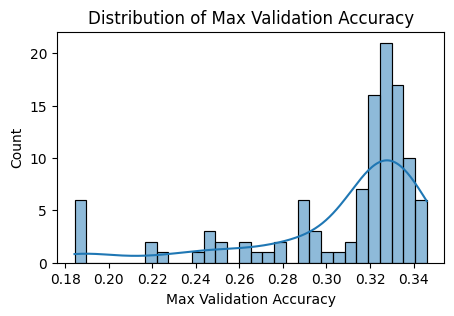

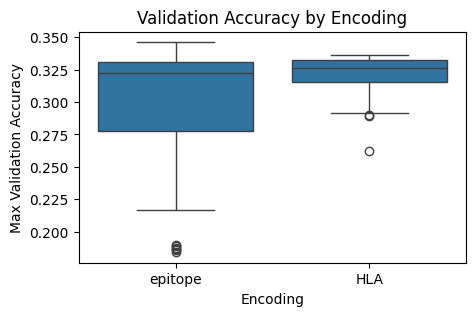

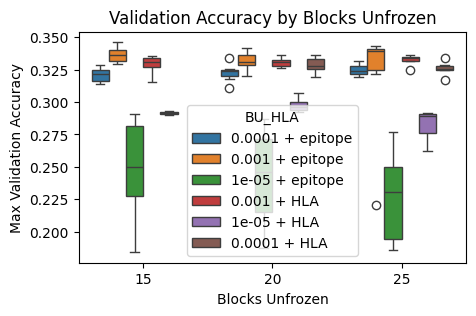

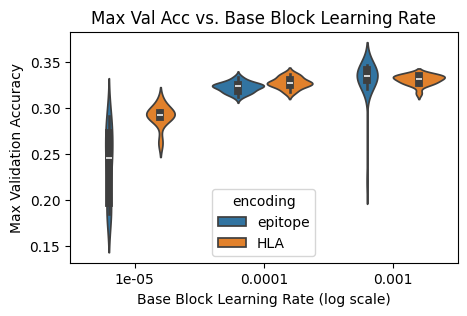

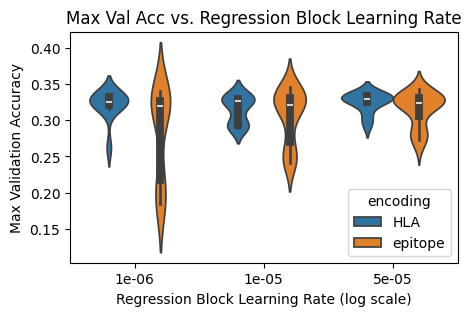

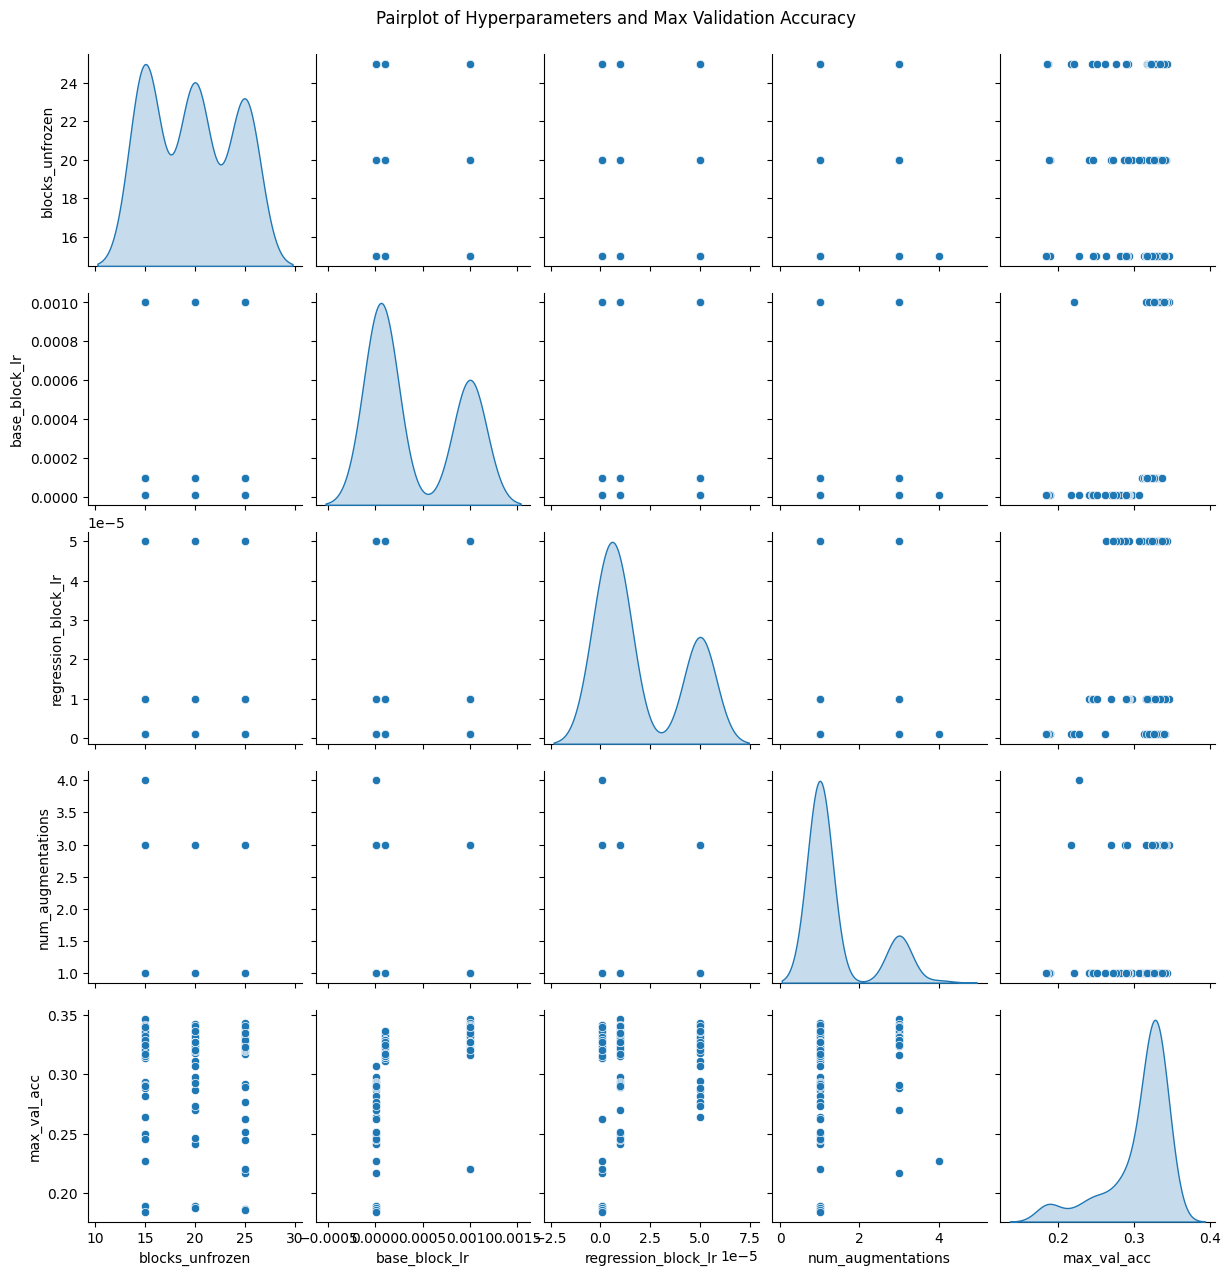

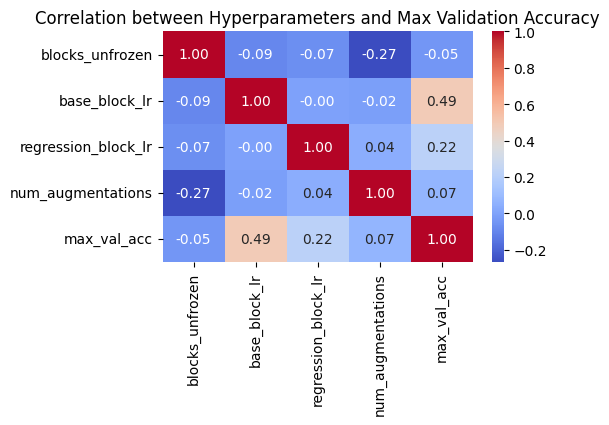

In [8]:
df_summary_subset = df_summary[df_summary['HLA_allele'] == 'A0201' ]

# 1. Histogram of max_val_acc
plt.figure(figsize=(5, 3))
sns.histplot(df_summary_subset['max_val_acc'], bins=30, kde=True)
plt.title("Distribution of Max Validation Accuracy")
plt.xlabel("Max Validation Accuracy")
plt.ylabel("Count")
plt.show()

# 2. Boxplot: Max Val Acc by Encoding
plt.figure(figsize=(5, 3))
sns.boxplot(x='encoding', y='max_val_acc', data=df_summary_subset)
plt.title("Validation Accuracy by Encoding")
plt.xlabel("Encoding")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 3. Boxplot: Max Val Acc by Number of Unfrozen Blocks (if only a few distinct values)
plt.figure(figsize=(5, 3))
sns.boxplot(x='blocks_unfrozen', y='max_val_acc', hue='BU_HLA', data=df_summary_subset)
plt.title("Validation Accuracy by Blocks Unfrozen")
plt.xlabel("Blocks Unfrozen")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 4. Scatter Plot: Base Block LR vs. Max Val Acc (using log scale for lr)
plt.figure(figsize=(5, 3))
sns.violinplot(x='base_block_lr', y='max_val_acc', hue='encoding', data=df_summary_subset)
# plt.xscale('log')
plt.title("Max Val Acc vs. Base Block Learning Rate")
plt.xlabel("Base Block Learning Rate (log scale)")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 5. Scatter Plot: Regression Block LR vs. Max Val Acc (using log scale)
plt.figure(figsize=(5, 3))
sns.violinplot(x='regression_block_lr', y='max_val_acc', hue='encoding', data=df_summary_subset)
# plt.xscale('log')
plt.title("Max Val Acc vs. Regression Block Learning Rate")
plt.xlabel("Regression Block Learning Rate (log scale)")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 6. Pairplot: Visualize all hyperparameters vs max_val_acc
selected_cols = ['blocks_unfrozen', 'base_block_lr', 'regression_block_lr', 'num_augmentations', 'max_val_acc']
sns.pairplot(df_summary_subset[selected_cols], diag_kind='kde')
plt.suptitle("Pairplot of Hyperparameters and Max Validation Accuracy", y=1.02)
plt.show()

# 7. Correlation Heatmap: Numerical hyperparameters and performance
corr_cols = ['blocks_unfrozen', 'base_block_lr', 'regression_block_lr', 'num_augmentations', 'max_val_acc']
corr_matrix = df_summary_subset[corr_cols].corr()
plt.figure(figsize=(5, 3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Hyperparameters and Max Validation Accuracy")
plt.show()


In [9]:
HLAs_done = Counter([x.split('AUG')[1].split('_')[2] for x in  glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_evals/*.csv')]).keys()

In [11]:
glob.glob(f'/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*B2703*.csv')

['/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/ESMMASK_HLA_FT_20_1e-05_1e-06_AUG_1_B2703_1_per_token_metrics.csv',
 '/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/ESMMASK_HLA_FT_15_1e-05_1e-06_AUG_1_B2703_1_per_token_metrics.csv',
 '/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/ESMMASK_HLA_FT_20_0.001_5e-05_AUG_4_B2703_2_per_token_metrics.csv',
 '/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/ESMMASK_HLA_FT_20_0.0001_1e-06_AUG_3_B2703_2_per_token_metrics.csv',
 '/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/ESMMASK_HLA_FT_15_1e-05_5e-05_AUG_3_B2703_2_per_token_metrics.csv',
 '/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/ESMMASK_epitope_FT_20_1e-05_5e-05_AUG_1_B2703_1_per_token_metrics.csv',
 '/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/ESMMASK_epitope_FT_25_0.001_1e-05_AUG_4_B2703_1_per_token_metr

In [12]:
import time
import itertools

summary = []

for HLA in HLAs_done:
    HLA = HLA.replace('HLA','')
    # 1. Load all CSV files into a dictionary of DataFrames.
    trained_files = glob.glob(f'/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*{HLA}*.csv')
    trained_files = sorted(trained_files)

    print(f"Found {len(trained_files)} files.")

    models = {}
    model_names = []
    for file in trained_files:

        if os.path.getsize(file) < 10:
            print(f"Skipping empty file: {file}")
            continue

        df = pd.read_csv(file)
        
        base = os.path.basename(file)
        # Remove common prefix and suffix to get a shorter model name.
        # For example: "training_log_ESMMASK_" and ".csv"
        name = base.replace("ESMMASK", "").replace(".csv", "").split('_HLA')[0]
        models[name] = df
        model_names.append(name)

        # Summarize average token_nll for each model
        avg_nll = df['token_nll'].mean()

        summary.append({
        'File': os.path.basename(file),
        'HLA': HLA,
        'Avg_Token_NLL': avg_nll
    })
    # for name, df in models.items():
    #     avg_nll[name] = df['token_nll'].mean()

    # # Sort by lowest average negative log-likelihood
    # best_models_by_nll = sorted(avg_nll.items(), key=lambda x: x[1])
    # print("Best models by average token NLL:")
    # for name, score in best_models_by_nll:
    #     print(f"{name}: {score:.4f}")

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by='Avg_Token_NLL')
summary_df = summary_df[summary_df['Avg_Token_NLL'] > 0 ]

Found 50 files.
Found 12 files.
Found 9 files.
Found 10 files.
Found 8 files.
Found 13 files.
Found 11 files.
Found 13 files.
Found 5 files.
Found 14 files.
Found 5 files.
Found 17 files.
Found 11 files.
Found 10 files.
Found 37 files.
Found 8 files.
Found 8 files.
Found 11 files.
Found 4 files.
Found 15 files.
Found 64 files.
Found 13 files.
Found 13 files.
Found 13 files.
Found 11 files.
Found 13 files.
Found 9 files.
Found 47 files.
Found 23 files.
Found 9 files.
Found 11 files.
Found 8 files.
Found 9 files.
Found 10 files.
Found 10 files.
Found 7 files.
Found 9 files.
Found 10 files.
Found 16 files.
Found 10 files.
Found 10 files.
Found 12 files.
Found 11 files.
Found 4 files.
Found 9 files.
Found 9 files.
Found 16 files.
Found 7 files.
Found 10 files.
Found 10 files.
Found 11 files.
Found 111 files.
Found 40 files.
Found 31 files.
Found 10 files.
Found 8 files.
Found 11 files.
Found 10 files.
Found 14 files.
Found 12 files.
Found 6 files.
Found 10 files.
Found 10 files.
Found 9 fi

In [13]:
sum_subset = summary_df[summary_df['Avg_Token_NLL'] > 0 ]

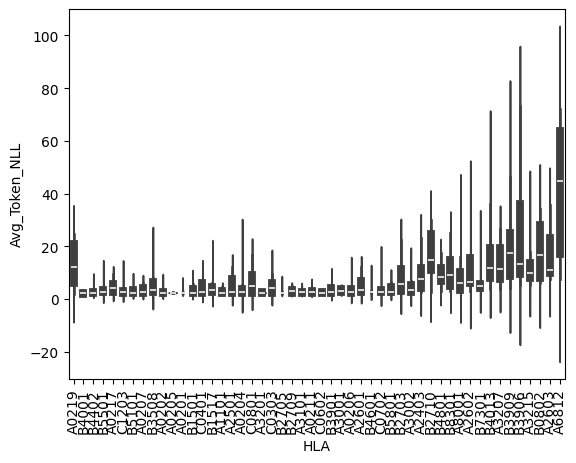

In [14]:
sns.violinplot(data = sum_subset[sum_subset['HLA'].isin(sum_subset['HLA'].value_counts().reset_index().head(50)['HLA'])],
                x = 'HLA',
                y= 'Avg_Token_NLL')

plt.xticks(rotation=90)
plt.show()

In [15]:
df_summary['HLA_allele'].value_counts().head(30)

HLA_allele
A0201    112
B4013     64
B3909     50
A1101     47
B4402     40
B5101     37
B2705     31
B1501     23
A3207     17
B3906     16
B1517     16
C0401     16
B4601     15
A3215     15
A0204     15
A6812     14
A0202     14
B2710     14
B8301     14
A3002     14
B3508     14
B5801     13
A2601     13
B4801     13
C0303     13
C0702     13
C1203     13
A2403     13
B7301     13
A2602     13
Name: count, dtype: int64

In [27]:
from pathlib import Path

Found 111 files.
_HLA_FT_15_0.001_1e-05_AUG_1_A0201_1: Accuracy = 0.315
_HLA_FT_15_0.001_1e-05_AUG_1_A0201_2: Accuracy = 0.322
_HLA_FT_15_0.001_1e-06_AUG_1_A0201_1: Accuracy = 0.318
_HLA_FT_15_0.001_1e-06_AUG_1_A0201_2: Accuracy = 0.315
_HLA_FT_15_0.001_5e-05_AUG_1_A0201_1: Accuracy = 0.335
_HLA_FT_15_0.001_5e-05_AUG_1_A0201_2: Accuracy = 0.317
_HLA_FT_15_1e-05_1e-05_AUG_1_A0201_1: Accuracy = 0.298
_HLA_FT_15_1e-05_1e-05_AUG_1_A0201_2: Accuracy = 0.293
_HLA_FT_20_0.0001_1e-05_AUG_1_A0201_1: Accuracy = 0.301
_HLA_FT_20_0.0001_1e-05_AUG_1_A0201_2: Accuracy = 0.313
_HLA_FT_20_0.0001_1e-06_AUG_1_A0201_1: Accuracy = 0.304
_HLA_FT_20_0.0001_1e-06_AUG_1_A0201_2: Accuracy = 0.306
_HLA_FT_20_0.0001_5e-05_AUG_1_A0201_1: Accuracy = 0.327
_HLA_FT_20_0.0001_5e-05_AUG_1_A0201_2: Accuracy = 0.317
_HLA_FT_20_0.001_1e-05_AUG_1_A0201_1: Accuracy = 0.318
_HLA_FT_20_0.001_1e-05_AUG_1_A0201_2: Accuracy = 0.310
_HLA_FT_20_0.001_1e-06_AUG_1_A0201_1: Accuracy = 0.330
_HLA_FT_20_0.001_1e-06_AUG_1_A0201_2: Accu

/tmp/ipykernel_2190687/3798552272.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


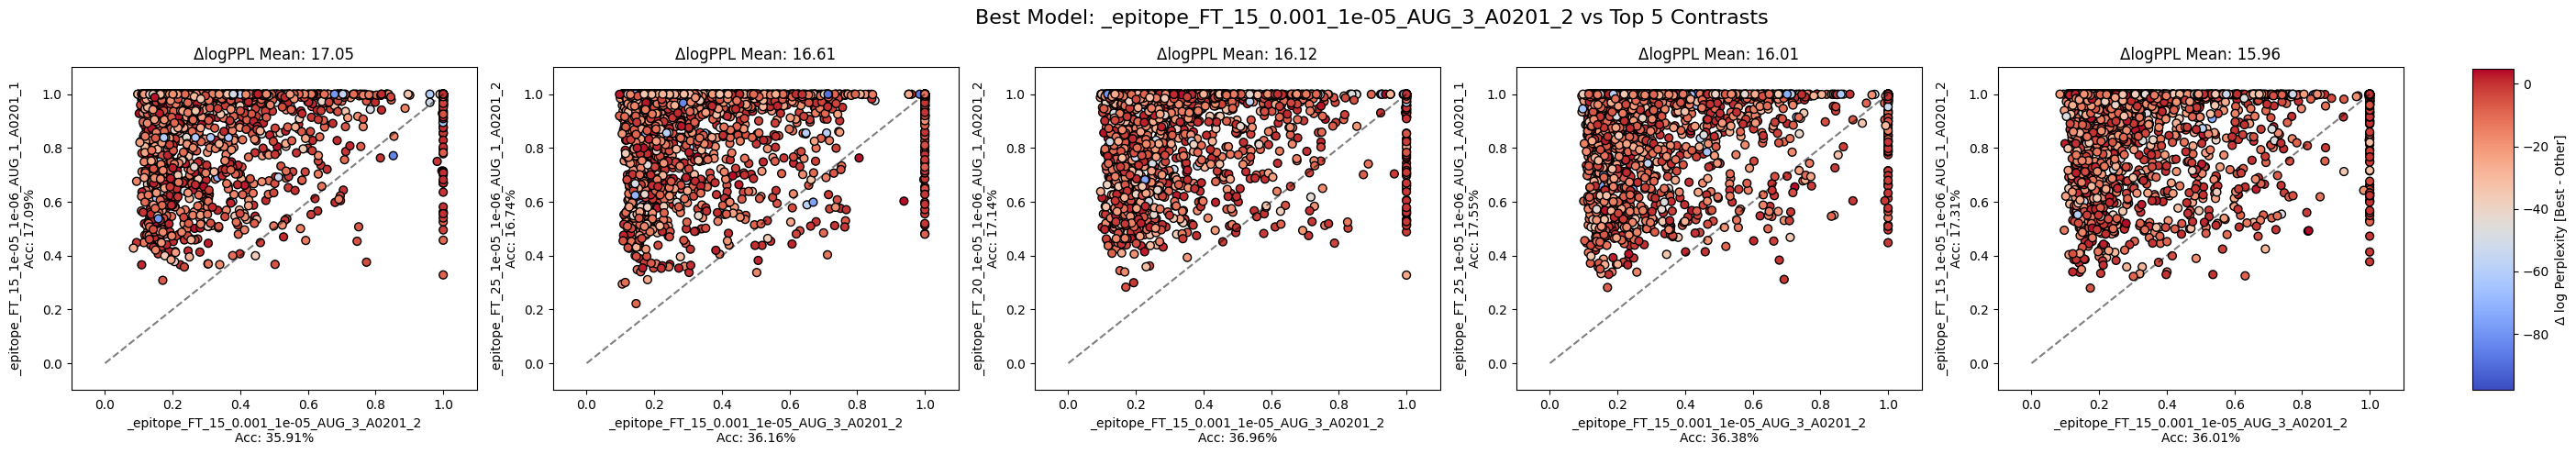

In [29]:
import glob
import os
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load models
trained_files = glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*A0201*.csv')
trained_files = sorted(trained_files)
print(f"Found {len(trained_files)} files.")

models = {}
accuracies = {}
model_names = []

for file in trained_files:
    df = pd.read_csv(file)
    base = os.path.basename(file)
    name = base.replace("ESMMASK", "").replace("_per_token_metrics.csv", "")
    models[name] = df
    model_names.append(name)

    # Compute accuracy
    if 'original_id' in df.columns and 'predicted_id' in df.columns:
        accuracy = (df['original_id'] == df['predicted_id']).mean()
        accuracies[name] = accuracy
        print(f"{name}: Accuracy = {accuracy:.3f}")

# Step 2: Select best model (based on accuracy)
best_model = max(accuracies, key=accuracies.get)
print(f"\nBest model: {best_model} with accuracy {accuracies[best_model]:.3f}")

# Step 3: Compare best model to all others and compute delta log perplexity
comparison_stats = []

for other_model in model_names:
    if other_model == best_model:
        continue

    df1 = models[best_model]
    df2 = models[other_model]

    df_merged = pd.merge(df1, df2, on=['epitope', 'original_id'], how='inner',
                         suffixes=('_model1', '_model2'))

    df_merged['delta_log_ppl'] = df_merged['token_nll_model1'] - df_merged['token_nll_model2']

    df_merged = df_merged.replace([np.inf, -np.inf], np.nan).dropna()

    acc_model1 = (df_merged['original_id'] == df_merged['predicted_id_model1']).mean()
    acc_model2 = (df_merged['original_id'] == df_merged['predicted_id_model2']).mean()

    mean_delta = np.abs(df_merged['delta_log_ppl']).mean()

    comparison_stats.append({
        'model2': other_model,
        'acc_model1': acc_model1,
        'acc_model2': acc_model2,
        'mean_delta_log_ppl': mean_delta,
        'df_merged': df_merged
    })

# Step 4: Sort comparisons by mean delta log perplexity and take top 5
top_comparisons = sorted(comparison_stats, key=lambda x: -x['mean_delta_log_ppl'])[:5]

# Step 5: Plot
fig, axes = plt.subplots(1, 5, figsize=(30, 5), squeeze=False)

for i, comp in enumerate(top_comparisons):
    ax = axes[0, i]
    df_merged = comp['df_merged']
    
    scatter_obj = ax.scatter(
        df_merged['predicted_prob_model1'],
        df_merged['predicted_prob_model2'],
        c=df_merged['delta_log_ppl'],
        cmap='coolwarm',
        s=40,
        edgecolor='k'
    )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)

    ax.set_xlabel(f"{best_model}\nAcc: {comp['acc_model1']:.2%}")
    ax.set_ylabel(f"{comp['model2']}\nAcc: {comp['acc_model2']:.2%}")
    ax.set_title(f"ΔlogPPL Mean: {comp['mean_delta_log_ppl']:.2f}")

# Colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(scatter_obj, cax=cbar_ax, label="Δ log Perplexity [Best - Other]")

fig.suptitle(f"Best Model: {best_model} vs Top 5 Contrasts", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.88, 1])

# # Save the figure with the HLA name in the specified folder.
# out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# out_dir.mkdir(parents=True, exist_ok=True)      
# save_path = out_dir / f"fig2a.pdf"
# fig = plt.gcf()                                 # or keep a handle from plt.subplots()
# fig.savefig(save_path, dpi=300, bbox_inches="tight")
# plt.close(fig)   

plt.show()


In [17]:
directory = '/global/scratch/users/sergiomar10/models/ESMC_Pretrain/'
summary_df['model_path'] = directory + 'HLA' + summary_df['HLA'] + '/' + summary_df['File'].str.replace('_per_token_metrics.csv','.pt')
# /global/scratch/users/sergiomar10/models/ESMC_Pretrain/HLAHLAB2703/ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAB2703_2.pt

In [18]:
summary_df = summary_df[summary_df['HLA'].apply(len) > 4]

In [19]:
summary_df['Encoding'] = summary_df['File'].str.split('_').str[1]

/tmp/ipykernel_2190687/2614477926.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])  # leave space for the global x‑label


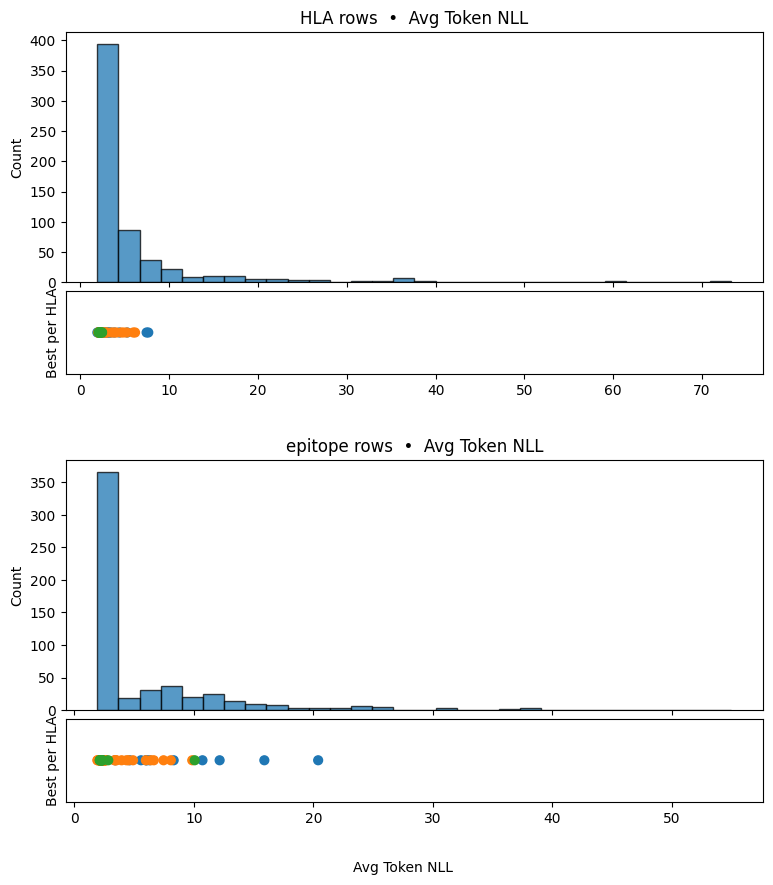

In [20]:
import matplotlib.gridspec as gridspec

thresh = 200                           # keep everything with Avg_Token_NLL < 200
enc_levels = ['HLA', 'epitope']        # order to plot

fig = plt.figure(figsize=(9, 10))
outer = gridspec.GridSpec(2, 1, hspace=0.25)   # two big rows (top / bottom)

for i, enc in enumerate(enc_levels):
    # -------------------------------------------------------------
    # 1. Filter by encoding and quality threshold
    # -------------------------------------------------------------
    enc_df = summary_df.loc[
        (summary_df['Encoding'] == enc) &
        (summary_df['Avg_Token_NLL'] < thresh)
    ]

    # “best” (lowest NLL) line per HLA, even for epitope‑encoded rows
    best = (enc_df.sort_values('Avg_Token_NLL')
                    .groupby('HLA', as_index=False)
                    .first())

    # -------------------------------------------------------------
    # 2. Build a nested 2×1 grid: hist on top, lollipop underneath
    # -------------------------------------------------------------
    gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[i],
        height_ratios=[3, 1], hspace=0.05
    )
    ax_hist  = plt.Subplot(fig, gs[0])
    ax_lolli = plt.Subplot(fig, gs[1], sharex=ax_hist)
    fig.add_subplot(ax_hist);  fig.add_subplot(ax_lolli)

    # Histogram
    ax_hist.hist(enc_df['Avg_Token_NLL'], bins=30,
                 alpha=0.75, edgecolor='black')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title(f"{enc} rows  •  Avg Token NLL")

    # Lollipop stems
    # ax_lolli.stem(best['Avg_Token_NLL'].values,
    #               np.zeros(len(best)),
    #               linefmt='-', markerfmt='o', basefmt=' ')
    ax_lolli.set_yticks([])
    ax_lolli.set_ylabel('Best per HLA')

    # Colour markers by HLA class (optional)
    family_colors = best['HLA'].str[0].map({'A':'tab:blue',
                                            'B':'tab:orange',
                                            'C':'tab:green'})
    ax_lolli.scatter(best['Avg_Token_NLL'], np.zeros(len(best)),
                     c=family_colors, s=40, zorder=3)

# Shared x‑label across both blocks
fig.text(0.5, 0.04, 'Avg Token NLL', ha='center')
plt.tight_layout(rect=[0, 0.04, 1, 1])  # leave space for the global x‑label
plt.show()


In [21]:
df_summary

,file,filename,encoding,blocks_unfrozen,base_block_lr,regression_block_lr,num_augmentations,HLA_allele,max_val_acc,BU_HLA
0,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_HLA_FT_15_0.001_5e-05_AUG...,HLA,15,0.00100,0.000050,1,B2705,0.3086,0.001 + HLA
1,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_epitope_FT_25_0.001_1e-06...,epitope,25,0.00100,0.000001,3,A6601,0.4079,0.001 + epitope
2,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_epitope_FT_20_1e-05_1e-06...,epitope,20,0.00001,0.000001,4,A6601,0.2036,1e-05 + epitope
3,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_HLA_FT_15_0.0001_1e-05_AU...,HLA,15,0.00010,0.000010,1,A0206,0.3205,0.0001 + HLA
4,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_epitope_FT_20_0.001_1e-05...,epitope,20,0.00100,0.000010,4,B1502,0.2870,0.001 + epitope
...,...,...,...,...,...,...,...,...,...,...
1330,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_HLA_FT_25_0.0001_1e-06_AU...,HLA,25,0.00010,0.000001,3,A8001,0.3913,0.0001 + HLA
1331,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_HLA_FT_20_1e-05_1e-05_AUG...,HLA,20,0.00001,0.000010,3,B4801,0.3684,1e-05 + HLA
1332,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_HLA_FT_15_0.0001_5e-05_AU...,HLA,15,0.00010,0.000050,1,B4601,0.2911,0.0001 + HLA
1333,/global/scratch/users/sergiomar10/logs/ESMC_Pr...,training_log_ESMMASK_epitope_FT_25_1e-05_5e-05...,epitope,25,0.00001,0.000050,3,B3909,0.3333,1e-05 + epitope


In [22]:
summary_df.to_csv('summary_of_pretrained_models.csv', index=False)

In [23]:
summary_df['Model'] = summary_df['HLA']  + '+' + summary_df['Encoding']

195


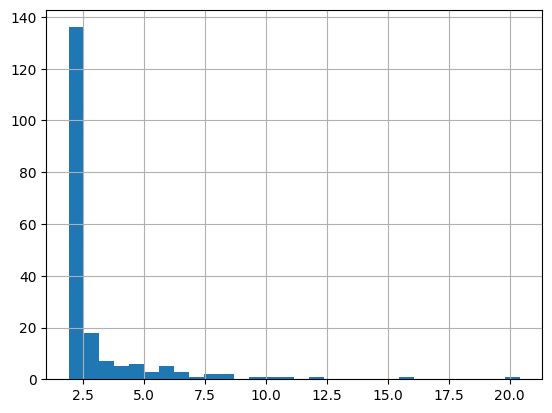

In [24]:
set_for_ba_set = summary_df.drop_duplicates('Model')
set_for_ba_set = set_for_ba_set.reset_index(drop=True)
set_for_ba_set[set_for_ba_set['Avg_Token_NLL'] < 200]['Avg_Token_NLL'].hist(bins=30)
print(len(set_for_ba_set))

In [ ]:
fsafas

In [25]:
# Function to check if a file path exists
def check_path(path):
    return os.path.exists(path)

# Apply the check to the model_path column
set_for_ba_set['path_exists'] = set_for_ba_set['model_path'].apply(check_path)

# Identify non-existent paths
non_existent_paths = set_for_ba_set[~set_for_ba_set['path_exists']][['model_path']]

# Optionally, filter DataFrame to keep only rows with existing paths
set_for_ba_set = set_for_ba_set[set_for_ba_set['path_exists']]

# Drop the temporary 'path_exists' column if not needed
set_for_ba_set = set_for_ba_set.drop(columns=['path_exists'])

KeyboardInterrupt: 

In [ ]:
set_for_ba_set.to_csv('file_paths.csv', index=False)

### Create SLURM files

In [ ]:
################################################
# 6. Define a simple FASTA parser
################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        # Append the last sequence if present
        if seq:
            sequences.append((header, seq))
    return sequences


############################################
# 7. Load and filter the data
############################################
train_fasta = "/global/scratch/users/sergiomar10/jupyter_notebooks/hla_protein_sequences.fasta"
all_data = parse_fasta(train_fasta)

filtered_data = []
for header, sequence in all_data:
    if sequence[0] != 'M':
        continue
    if len(sequence) < 50:
        continue
    if 'X' in sequence:
        continue

    header = header.split('|')[1][:7].replace('*','').replace(':','')

    filtered_data.append(('HLA' + header))
    

In [ ]:
import os

#########################################################
# FASTA Parser
#########################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        if seq:
            sequences.append((header, seq))
    return sequences

#########################################################
# Load HLA Sequences
#########################################################
fasta_path = "/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/hla_sequences.fasta"
hla_data = parse_fasta(fasta_path)

hla_sequences = [
    header for header, seq in hla_data
]


In [ ]:
hla_sequences = [x.replace('*','').replace(':','') for x in hla_sequences]

In [ ]:
HLAs = hla_sequences

In [ ]:
import itertools
import os
import glob

script_path = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/models/ESM_Unsupervised/ESM-C_ALLHLAs.py'
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/ESMC_pretrain3'
os.makedirs(sh_file_dir, exist_ok=True)

trials = [1, 2]
encoding = ['epitope', 'HLA']
blocks_unfrozen = [15, 20, 25]
last_block_lr = [1e-3, 1e-4, 1e-5]
regression_block_lr = [1e-6, 5e-5, 1e-5]
num_augmentations = [1, 3, 4]
                    
for trial_n, encode, num_block, lr_base, lr_reg, HLA, augs  in itertools.product(trials, encoding, blocks_unfrozen, last_block_lr, regression_block_lr, HLAs, num_augmentations):
    
    file_name = f'ESMMASK_{encode}_FT_{num_block}_{lr_base}_{lr_reg}_AUG_{augs}_{HLA}_{trial_n}'

    sh_filename = f'{file_name}.sh'
    sh_filepath = os.path.join(sh_file_dir, sh_filename)
    
    # Construct the command to run the script with the current parameters
    cmd = f'python3 {script_path} --name_of_model {file_name} --encoding {encode} --blocks_unfrozen {num_block} --base_block_lr {lr_base} --regression_block_lr {lr_reg} --HLA HLA{HLA} --num_augmentations {augs}'

    with open(sh_filepath, 'w') as sh_file:
        sh_file.write('#!/bin/bash\n')
        sh_file.write('#SBATCH --account=co_nilah\n')
        sh_file.write('#SBATCH --partition=savio2_1080ti\n')
        sh_file.write('#SBATCH --qos=savio_lowprio\n')
        sh_file.write('#SBATCH --cpus-per-task=4\n')
        sh_file.write('#SBATCH --gres=gpu:1\n')
        sh_file.write('#SBATCH --requeue\n')
        sh_file.write('#SBATCH --time=03:00:00\n')
        sh_file.write(f'#SBATCH --job-name={file_name}\n')
        sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.out\n')
        sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.err\n')
        sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
        sh_file.write('\n')
        sh_file.write('conda activate ESM_cambrian\n')
        sh_file.write('\n')

        sh_file.write(cmd + '\n')
        
    # Make the shell script executable
    os.chmod(sh_filepath, 0o755)
    
    print(f'Created shell script: {file_name}')
    # break


Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0204_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0204_1
Created shell script